# Train an imputation model

Loss here is based on 

      loss = torch.mean(
            (1.0 - self.noise2self_ratio) * rec_loss_n
            + self.noise2self_ratio * noise2self_rec_loss_n
            + kl_annealing_weight
            * (self.z_kl_weight_max * kl_divergence_z + self.batch_kl_weight_max * kl_divergence_batch),
            dim=0,
        )

      where self.noise2self_ratio is annealed same as KL divergence annealing.
    

In this notebook, for a fair comparison, we mask half and predict on the rest for the all the masking probabilities tested. For example, even if masking probability is 3%, we train using the 3% masking probability. However, when testing we mask 50% and predict on the other half.

Follow this example: https://cellarium-ai.github.io/cellarium-ml/tutorials/part_i.html

In [29]:
from cellarium.ml import CellariumAnnDataDataModule, CellariumModule
from cellarium.ml.data import read_h5ad_file
from cellarium.ml.data import DistributedAnnDataCollection
from cellarium.ml.utilities.data import AnnDataField, collate_fn, densify, categories_to_codes
from cellarium.ml.callbacks import PredictionWriter
from cellarium.ml.data.dadc_dataset import IterableDistributedAnnDataCollectionDataset
from cellarium.ml.models import ImputationModel_Annealing, ImputationModel

import lightning.pytorch as pl
from lightning.pytorch.loggers import CSVLogger
import pandas as pd
import numpy as np
import anndata as ad
import glob
import os
import torch
import matplotlib.pyplot as plt
import scanpy as sc
import scipy.sparse as sp
import seaborn as sns
import shutil
import pickle
import random

from sklearn.model_selection import train_test_split
from cellarium.ml.data.fileio import read_h5ad_file

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix


# Functions

In [30]:
def set_seed(seed: int):
    """Set the random seed for reproducibility."""
    
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.use_deterministic_algorithms(True)
    torch.backends.cudnn.benchmark = False

In [9]:
def mask_data(adata, masking_probability, random_seed):
    """
    Randomly mask a fraction of genes per cell in an AnnData object.

    Parameters
    ----------
    adata : AnnData
        Input AnnData object (n_obs x n_vars).
    mask_fraction : float
        Fraction of genes to mask per cell (e.g., 0.2 = 20%).
    mask_value : float or np.nan
        Value to assign to masked positions (default 0.0).
    layer_key : str
        Key in adata.layers where masked data will be stored.
    seed : int or None
        Random seed for reproducibility.

    Returns
    -------
    masked_adata : AnnData
        New AnnData object with:
          - masked counts in `.X` and `.layers[layer_key]`
          - mask matrix in `.layers[f"mask_{int(masking_probability*100)}"]`
          - per-cell mask indices in `.obs[f"masked_gene_indices_{int(masking_probability*100)}"]`
    """

    rng = np.random.default_rng(random_seed)
    
    n_cells, n_genes =  adata.X.shape
    n_mask = int(masking_probability * n_genes)
    print(f"Masking {n_mask} genes out of {n_genes} ({masking_probability*100}%) per cell.")
    
    # Create mask matrix of all zeros of shape (n_cells, n_genes)
    mask = np.zeros(adata.X.shape, dtype=bool)
  
    masked_indices_per_cell = []
    # For each cell, randomly select n_mask gene indices to mask
    for i in range(n_cells):
        # print(f"Processing cell {i+1}/{n_cells}")
        # Randomly choose n_mask unique gene indices
        mask_indices = rng.choice(n_genes, n_mask, replace=False)
        mask[i, mask_indices] = True
        masked_indices_per_cell.append(mask_indices)

    X_masked = adata.X.copy()
    # Apply the mask: set masked positions to 0
    X_masked[mask] = 0

    # Create new AnnData to store masked data and mask matrix
    masked_adata = ad.AnnData(X_masked, obs=adata.obs.copy(), var=adata.var.copy())
    masked_adata.layers["X_masked"] = X_masked
    masked_adata.layers[f"mask_{int(masking_probability*100)}"] = mask.astype(np.int8)
    masked_adata.obsm = adata.obsm.copy()

    # Store which gene indices were masked per cell (as strings for convenience)
    masked_adata.obs[f"masked_gene_indices_{int(masking_probability*100)}"] = [
        ",".join(map(str, idxs)) for idxs in masked_indices_per_cell
    ]

    # Create DataModule for masked data
    dm_mask= CellariumAnnDataDataModule(
            dadc=masked_adata,
            batch_keys={
                "x_ng": AnnDataField(attr="X", convert_fn=densify),
                "var_names_g": AnnDataField(attr="var_names"),
                "obs_names_n": AnnDataField(attr="obs_names"),
                "batch_index_n": AnnDataField(attr="obs", key="batch", convert_fn=categories_to_codes),
            },
            batch_size=512,
            shuffle=False,
        )  

    return masked_adata, dm_mask, masked_indices_per_cell

In [10]:
def save_predictions_latent(predictions, prediction_path, adata, label, prob):
    """
    Save prediction latent representations with proper labeling.
    
    Parameters
    ----------
    predictions : list
        List of prediction batches
    prediction_path : str
        Base path for saving predictions
    adata : AnnData
        AnnData object to store results
    label : str
        Label for the predictions ('whole' or 'masked')
    prob : float
        Masking probability used
    """

    # Create subdirectory for this prediction type
    pred_path = os.path.join(prediction_path, label)
    os.makedirs(pred_path, exist_ok=True)
    
    # Load and combine all batches
    dfs = []
    for file in glob.glob(os.path.join(prediction_path, f'batch_*')):
        dfs.append(pd.read_csv(file, index_col=0, header=None))
    latent_df = pd.concat(dfs, axis=0)
    latent_df = latent_df.loc[adata.obs_names]
    
    # Move batch files in prediction_path to pred_path
    batch_files = glob.glob(os.path.join(prediction_path, f'batch_*'))

    for src in batch_files:
        base = os.path.basename(src)
        dest = os.path.join(pred_path, base)
        try:
            shutil.move(src, dest)
        except Exception:
            if os.path.exists(dest):
                try:
                    os.remove(dest)
                except Exception as e:
                    raise RuntimeError(f"Could not remove existing destination {dest}: {e}") from e
            shutil.move(src, dest)

    return latent_df.values

def train_and_predict_imputation(imputation_module, adata, dm, masking_prob, n2s_weight, prediction_base_path='runs/imputation_annealing'):
    """
    Train imputation model and perform both whole dataset and masked predictions.
    
    Parameters
    ----------
    imputation_module : CellariumModule
        Imputation model to be trained
    adata : AnnData
        Input dataset
    dm : CellariumAnnDataDataModule
        Data module for training
    masking_prob : float
        Probability for masking genes
    n2s_weight : float
        Noise2Self weight for the model
    prediction_base_path : str
        Base path for storing predictions
        
    Returns
    -------
    dict
        Dictionary containing whole and masked predictions, 
        whole and masked latent representations, 
        and masked gene indices.
    """

    # Setup paths and names
    name_label = f"mask{int(masking_prob*100)}_n2s{int(n2s_weight*100)}"
    prediction_path = f"{prediction_base_path}/predictions_{name_label}"
    
    # Define imputation module
    print(f"\nDefining imputation module with masking_probability={masking_prob} and noise2self_weight={n2s_weight}")
    # Train model
    print(f"Training model...")
    logger = CSVLogger("logs", name=f"imputation_{name_label}")
    trainer = pl.Trainer(
        accelerator="cpu",
        precision="32-true",
        devices=1,
        max_epochs=20,
        default_root_dir=f"{prediction_base_path}_{name_label}/",
        logger=logger,
        callbacks=[PredictionWriter(output_dir=prediction_path)])
    trainer.fit(imputation_module, dm)
    
    # Get metrics from the trained model
    imputation_module.eval()
    batch = next(iter(dm.train_dataloader()))
    batch = {k: v for k, v in batch.items() if k in {"x_ng", "batch_index_n","var_names_g"}}
    print(batch.keys())
    with torch.no_grad():
        metric_outputs = imputation_module.model(**batch)
    print(f"Loss: {metric_outputs['loss'].item():.4f}")
    print(f"Reconstruction Loss: {metric_outputs['reconstruction_loss'].mean().item():.4f}")
    print(f"Noise2Self Rec Loss: {metric_outputs['noise2self_rec_loss_n'].mean().item():.4f}")
    print(f"KL Divergence Z: {metric_outputs['kl_divergence_z'].mean().item():.4f}")
    print(f"KL Annealing Weight: {metric_outputs['kl_annealing_weight']:.4f}")

    # Predict on the whole dataset
    print("Predicting on whole dataset...")
    whole_predictions = trainer.predict(imputation_module, dm)
    whole_collated = collate_fn(whole_predictions)
    latent_whole = save_predictions_latent(whole_collated, prediction_path, adata, 'whole', masking_prob)

    # Create and predict on masked dataset
    print("Predicting on masked dataset...")
    masked_adata, dm_mask, masked_indices = mask_data(dm.dadc, masking_probability=0.5, random_seed=42)
    masked_predictions = trainer.predict(imputation_module, dm_mask)
    masked_collated = collate_fn(masked_predictions)
    latent_masked = save_predictions_latent(masked_collated, prediction_path, adata, 'masked', masking_prob)    
    
    return {
        f"{name_label}_whole": whole_collated,
        f"{name_label}_masked": masked_collated,
        f"{name_label}_latent_whole": latent_whole,
        f"{name_label}_latent_masked":latent_masked,
        f"{name_label}_masked_gene_indices": masked_indices,
        f"{name_label}_output_metrics": metric_outputs
    }


In [11]:
def train_classifiers(X_train, y_train):
    """Train multiple classifier models on the provided training data."""

    # Multinomial Logistic Regression -- this is considered to be a strong baseline model for cell type classification 
    print("Training Logistic Regression model...") 
    lr_model = LogisticRegression(multi_class="multinomial", solver="lbfgs", max_iter=1000)
    lr_model.fit(X_train, y_train)

    # Random Forest Classifier
    print("Training Random Forest model...")
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)

    # Support Vector Machine Classifier
    print("Training SVM model...")
    svm_model = SVC(gamma='auto', random_state=42)
    svm_model.fit(X_train, y_train)

    return lr_model, rf_model, svm_model

In [12]:
def evaluate_classifiers(models, X_test, y_test, prob, noise2self_ratio):
    """Evaluate the trained classifiers on the test data and print classification reports."""
    
    model_names = ["Logistic Regression", "Random Forest", "SVM"]
    model_names_shortcut = ["LR", "RF", "SVM"]
    metrics_df = []
    for model, name in zip(models, model_names):
        print(f"\nEvaluating {name} model for masking probability {prob}...")
        y_pred = model.predict(X_test)
        report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

        # --- Extract per-class metrics ---
        for cell_type, stats in report.items():
            if cell_type in ["accuracy", "macro avg", "weighted avg"]:
                continue

            metrics_df.append({
                "classifier": model_names_shortcut[model_names.index(name)],
                "masking_prob": prob,
                "noise2self_ratio": noise2self_ratio,
                "cell_type": cell_type,
                "precision": stats["precision"],
                "recall": stats["recall"],
                "f1_score": stats["f1-score"],
            })

    return pd.DataFrame(metrics_df)


### CellariumAnnDataDataModule for 10k pbmc count data

In [31]:
data_path = "/Users/aseelawdeh/Documents/stephen_scvi/pbmc_count.h5ad"
adata = read_h5ad_file(data_path)

In [32]:
dm = CellariumAnnDataDataModule(
            dadc = adata,
            batch_keys={
                "x_ng": AnnDataField(attr="raw.X", convert_fn=densify),
                "var_names_g": AnnDataField(attr="var_names"),
                "obs_names_n": AnnDataField(attr="obs_names"),
                "batch_index_n": AnnDataField(attr="obs", key="batch",convert_fn=categories_to_codes)
                },
            batch_size=512,
            shuffle=False,
            #shuffle_seed=0
        )

### Imputation Model with Annealing

In [33]:
collated_predictions = {}

In [ ]:
# Train imputation models with different masking probabilities and save predictions in separate folder
masking_prob = 0.5
seeds_range = range(5) # Start from a different initial random state.
max_annealing_weights = [0.05, 0.2, 0.5, 0.7, 0.9, 1]

for seed in seeds_range:
    prediction_base_path= f'runs/imputation_annealing/seed{seed}'
    print(f"\nRunning seed {seed}")
    set_seed(seed)

    for weight in max_annealing_weights:
        print(f"\nProcessing max annealing weight: {weight}")

        # Create a fresh copy of adata for this max annealing weight
        adata_run = adata.copy()

        # Define imputation module
        imputation_module = CellariumModule(
            model=ImputationModel_Annealing(
                var_names_g=dm.dadc.var_names,
                n_batch=10,
                n_latent=20,
                masking_probability=masking_prob,
                noise2self_ratio_max=weight,
                noise2self_warmup_epochs=8,
                encoder={
                    "hidden_layers": [
                        {"class_path": "torch.nn.Linear", "init_args": {"out_features": 128}}
                    ],
                    "final_layer": {"class_path": "torch.nn.Linear", "init_args": {}},
                },
                decoder={
                    "hidden_layers": [
                        {"class_path": "torch.nn.Linear", "init_args": {"out_features": 128}}
                    ],
                    "final_layer": {"class_path": "torch.nn.Linear", "init_args": {}},
                    "final_additive_bias": False,
                },
                dropout_rate=0.1,
                dispersion="gene",
                log_variational=True,
                gene_likelihood="nb",
                latent_distribution="normal"
            ),
            optim_fn=torch.optim.AdamW,
            optim_kwargs={"lr": 1e-4}
        )

        # Train and get predictions for this masking probability
        # Predictions includes: "{name_label}_whole", "{name_label}_masked", "{name_label}_latent_whole", "{name_label}_latent_masked", "{name_label}_masked_gene_indices"
        predictions = train_and_predict_imputation(imputation_module, adata_run, dm, masking_prob, weight, prediction_base_path=prediction_base_path)
        # mask50_n2s90_masked
        latent_representation = predictions[f"mask{int(masking_prob*100)}_n2s{int(weight*100)}_latent_masked"]
        cell_labels = adata.obs["final_annotation"]

        # Split the data into training and testing sets (80% train, 20% test)
        X_train, X_test, y_train, y_test = train_test_split(latent_representation, cell_labels, test_size=0.2, random_state=42, stratify=cell_labels)

        # Train the classifiers
        lr_model, rf_model, svm_model = train_classifiers(X_train=X_train, y_train=y_train)
            
        # Evaluate the classifiers
        metrics_df = evaluate_classifiers(models=[lr_model, rf_model, svm_model], X_test=X_test, y_test=y_test, prob=masking_prob, noise2self_ratio=weight)
        metrics_df.to_csv(f"metrics_parameter_sweep/with_annealing/mask{int(masking_prob*100)}_n2s{int(weight*100)}_seed{seed}_parameter_sweep_metrics.csv", index=False)

In [18]:
collated_predictions.keys()

dict_keys(['mask50_whole', 'mask50_masked'])

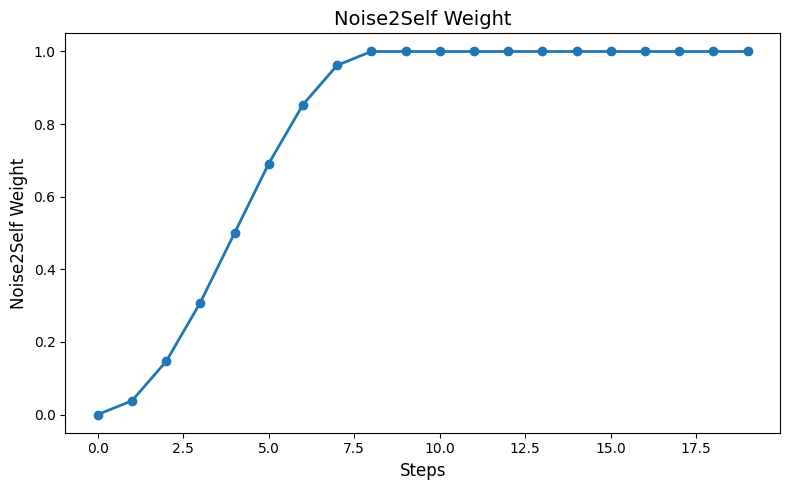

In [13]:
# Plot noise2self_weight per epoch
# read metrics file 
df_metrics = pd.read_csv("logs/with_annealing/imputation_mask50_n2s100/version_0/metrics.csv")
# drop out nan rows for nosie2self_weight
df_metrics = df_metrics.dropna(subset=["noise2self_weight"])
df_metrics = df_metrics["noise2self_weight"].astype(float)
df_metrics = df_metrics.reset_index()
 
plt.figure(figsize=(8, 5))
plt.plot(df_metrics["noise2self_weight"], marker="o", linewidth=2)
plt.xlabel("Steps", fontsize=12)
plt.ylabel("Noise2Self Weight", fontsize=12)
plt.title("Noise2Self Weight", fontsize=14)
plt.tight_layout()
plt.show()
 

# Training without annealing

In [ ]:
# Train imputation models with different masking probabilities and save predictions in separate folder
masking_prob = 0.5
max_annealing_weights = [0.05, 0.2, 0.5, 0.7, 0.9, 1]
seeds_range = range(5) # Start from a different initial random state.

for seed in seeds_range:
    prediction_base_path= f'runs/imputation_noannealing/seed{seed}'
    print(f"\nRunning seed {seed}")
    set_seed(seed)

    for weight in max_annealing_weights:
        print(f"\nProcessing max annealing weight: {weight}")

        # Create a fresh copy of adata for this max annealing weight
        adata_run = adata.copy()

        # Define imputation module
        imputation_module = CellariumModule(
            model=ImputationModel_Annealing(
                var_names_g=dm.dadc.var_names,
                n_batch=10,
                n_latent=20,
                masking_probability=masking_prob,
                noise2self_weight=weight,
                anneal_noise2self=False,
                noise2self_warmup_epochs=8,
                encoder={
                    "hidden_layers": [
                        {"class_path": "torch.nn.Linear", "init_args": {"out_features": 128}}
                    ],
                    "final_layer": {"class_path": "torch.nn.Linear", "init_args": {}},
                },
                decoder={
                    "hidden_layers": [
                        {"class_path": "torch.nn.Linear", "init_args": {"out_features": 128}}
                    ],
                    "final_layer": {"class_path": "torch.nn.Linear", "init_args": {}},
                    "final_additive_bias": False,
                },
                dropout_rate=0.1,
                dispersion="gene",
                log_variational=True,
                gene_likelihood="nb",
                latent_distribution="normal"
            ),
            optim_fn=torch.optim.AdamW,
            optim_kwargs={"lr": 1e-4}
        )

        # Train and get predictions for this masking probability
        # Predictions includes: "{name_label}_whole", "{name_label}_masked", "{name_label}_latent_whole", "{name_label}_latent_masked", "{name_label}_masked_gene_indices"
        predictions = train_and_predict_imputation(imputation_module, adata_run, dm, masking_prob, weight, prediction_base_path=prediction_base_path)
        # mask50_n2s90_masked
        latent_representation = predictions[f"mask{int(masking_prob*100)}_n2s{int(weight*100)}_latent_masked"]
        cell_labels = adata.obs["final_annotation"]

        # Split the data into training and testing sets (80% train, 20% test)
        X_train, X_test, y_train, y_test = train_test_split(latent_representation, cell_labels, test_size=0.2, random_state=42, stratify=cell_labels)

        # Train the classifiers
        lr_model, rf_model, svm_model = train_classifiers(X_train=X_train, y_train=y_train)
            
        # Evaluate the classifiers
        metrics_df = evaluate_classifiers(models=[lr_model, rf_model, svm_model], X_test=X_test, y_test=y_test, prob=masking_prob, noise2self_ratio=weight)
        metrics_df.to_csv(f"metrics_parameter_sweep/without_annealing/mask{int(masking_prob*100)}_n2s{int(weight*100)}_seed{seed}_parameter_sweep_metrics.csv", index=False)

# Analyze metrics from classifiers on latent representation

In [16]:
import pandas as pd
import glob

# Load all result files
files = glob.glob("metrics_parameter_sweep/without_annealing/*.csv")  # adjust path
df_noanneal = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

# Sanity check
print(df_noanneal.head())
print(df_noanneal[['classifier','masking_prob','noise2self_ratio']].drop_duplicates().shape)

  classifier  masking_prob  noise2self_ratio        cell_type  precision  \
0         LR           0.5               1.0    CD10+ B cells   0.942857   
1         LR           0.5               1.0  CD14+ Monocytes   0.954093   
2         LR           0.5               1.0  CD16+ Monocytes   0.600000   
3         LR           0.5               1.0    CD20+ B cells   0.982639   
4         LR           0.5               1.0     CD4+ T cells   0.806355   

     recall  f1_score  
0  0.804878  0.868421  
1  0.983438  0.968544  
2  0.130435  0.214286  
3  0.984348  0.983493  
4  0.979564  0.884560  
(18, 3)


### Load metrics files per masking probability, noise2self ratio and seed 

#### with annealing (cosine scheduler)

In [63]:
import pandas as pd 
import glob 

# Load all result files with *seed* in the name -- include what seed it was as a column in the dataframe
files = glob.glob("metrics_parameter_sweep/with_annealing/cosine/*seed*.csv")
dfs = []
for f in files:
    df = pd.read_csv(f)
    # Extract seed from filename, assuming format like "mask50_n2s90_seed0_parameter_sweep_metrics.csv"
    seed = f.split("seed")[1].split("_")[0]  # This will get the number after "seed" and before the next "_"
    df['seed'] = int(seed)  # Add seed as a column
    dfs.append(df)
df_with_anneal = pd.concat(dfs, ignore_index=True)
df_with_anneal = df_with_anneal.sort_values(by=['seed', 'classifier', 'masking_prob', 'noise2self_ratio']).reset_index(drop=True)
df_with_anneal

,classifier,masking_prob,noise2self_ratio,cell_type,precision,recall,f1_score,seed
0,LR,0.5,0.05,CD10+ B cells,0.906977,0.951220,0.928571,0
1,LR,0.5,0.05,CD14+ Monocytes,0.954580,0.977918,0.966108,0
2,LR,0.5,0.05,CD16+ Monocytes,0.375000,0.130435,0.193548,0
3,LR,0.5,0.05,CD20+ B cells,0.993007,0.987826,0.990410,0
4,LR,0.5,0.05,CD4+ T cells,0.803188,0.984105,0.884490,0
...,...,...,...,...,...,...,...,...
1435,SVM,0.5,1.00,Monocyte-derived dendritic cells,0.791209,0.750000,0.770053,4
1436,SVM,0.5,1.00,NK cells,0.825980,0.734205,0.777393,4
1437,SVM,0.5,1.00,NKT cells,0.720074,0.712204,0.716117,4
1438,SVM,0.5,1.00,Plasma cells,0.782609,0.692308,0.734694,4


#### without annealing

In [47]:
import pandas as pd 
import glob 

# Load all result files with *seed* in the name -- include what seed it was as a column in the dataframe
files = glob.glob("metrics_parameter_sweep/without_annealing/*seed*.csv")
dfs = []
for f in files:
    df = pd.read_csv(f)
    # Extract seed from filename, assuming format like "mask50_n2s90_seed0_parameter_sweep_metrics.csv"
    seed = f.split("seed")[1].split("_")[0]  # This will get the number after "seed" and before the next "_"
    df['seed'] = int(seed)  # Add seed as a column
    dfs.append(df)
df_without_anneal = pd.concat(dfs, ignore_index=True)
df_without_anneal = df_without_anneal.sort_values(by=['seed', 'classifier', 'masking_prob', 'noise2self_ratio']).reset_index(drop=True)
df_without_anneal

,classifier,masking_prob,noise2self_ratio,cell_type,precision,recall,f1_score,seed
0,LR,0.5,0.05,CD10+ B cells,0.904762,0.926829,0.915663,0
1,LR,0.5,0.05,CD14+ Monocytes,0.954755,0.981861,0.968118,0
2,LR,0.5,0.05,CD16+ Monocytes,0.400000,0.086957,0.142857,0
3,LR,0.5,0.05,CD20+ B cells,0.992970,0.982609,0.987762,0
4,LR,0.5,0.05,CD4+ T cells,0.803042,0.983197,0.884034,0
...,...,...,...,...,...,...,...,...
1435,SVM,0.5,1.00,Monocyte-derived dendritic cells,0.774194,0.750000,0.761905,4
1436,SVM,0.5,1.00,NK cells,0.833333,0.740741,0.784314,4
1437,SVM,0.5,1.00,NKT cells,0.727440,0.719490,0.723443,4
1438,SVM,0.5,1.00,Plasma cells,0.782609,0.692308,0.734694,4


In [52]:
macro_anneal = (
    df_with_anneal
    .groupby(["noise2self_ratio"])
    .agg(
        macro_precision=("precision", "mean"),
        macro_recall=("recall", "mean"),
        macro_f1=("f1_score", "mean"),
        n_cell_types=("cell_type", "nunique"),
    )
    .reset_index()
)
macro_anneal

,noise2self_ratio,macro_precision,macro_recall,macro_f1,n_cell_types
0,0.05,0.775637,0.707522,0.718543,16
1,0.20,0.787444,0.714401,0.726039,16
2,0.50,0.771938,0.711844,0.723939,16
3,0.70,0.767427,0.710439,0.720408,16
4,0.90,0.771479,0.709269,0.720466,16
5,1.00,0.750188,0.690498,0.702613,16


In [53]:
macro_noanneal = (
    df_without_anneal
    .groupby(["noise2self_ratio"])
    .agg(
        macro_precision=("precision", "mean"),
        macro_recall=("recall", "mean"),
        macro_f1=("f1_score", "mean"),
        n_cell_types=("cell_type", "nunique"),
    )
    .reset_index()
)
macro_noanneal

,noise2self_ratio,macro_precision,macro_recall,macro_f1,n_cell_types
0,0.05,0.751877,0.704320,0.714160,16
1,0.20,0.773355,0.705173,0.717114,16
2,0.50,0.772664,0.705059,0.718247,16
3,0.70,0.755889,0.705855,0.715764,16
4,0.90,0.771479,0.709269,0.720466,16
5,1.00,0.749464,0.692862,0.704444,16


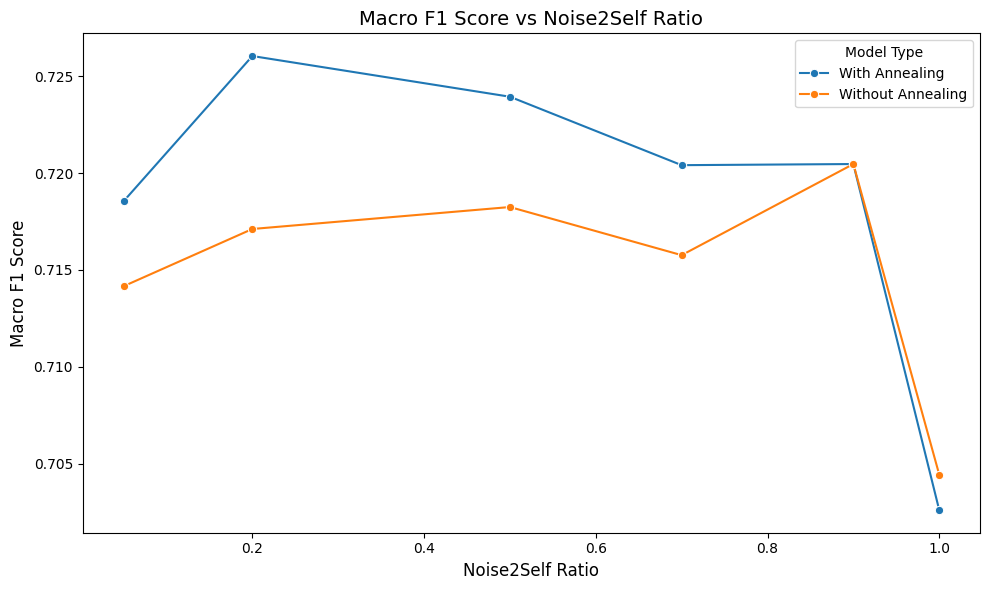

In [54]:
# plot line graph of macro_by_ns2_noanneal macro f1 score per noise2self_ratio and  macro_by_ns2_noanneal f1 score per noise2self raiton
# in different colors 
# x axis is the noise2self ration, y axis is the macro f1 score
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.lineplot(data=macro_anneal, x="noise2self_ratio", y="macro_f1", marker="o", label="With Annealing")
sns.lineplot(data=macro_noanneal, x="noise2self_ratio", y="macro_f1", marker="o", label="Without Annealing")
plt.xlabel("Noise2Self Ratio", fontsize=12)
plt.ylabel("Macro F1 Score", fontsize=12)
plt.title("Macro F1 Score vs Noise2Self Ratio", fontsize=14)
plt.legend(title="Model Type")
plt.tight_layout()
plt.show()


In [ ]:
# Compute macro-F1 per seed
macro_anneal_seed = (
    df_with_anneal
    .groupby(["seed", "noise2self_ratio"])
    .agg(macro_f1=("f1_score", "mean"))
    .reset_index()
)

macro_noanneal_seed = (
    df_without_anneal
    .groupby(["seed", "noise2self_ratio"])
    .agg(macro_f1=("f1_score", "mean"))
    .reset_index()
)

macro = macro_anneal_seed.merge(
    macro_noanneal_seed,
    on=["seed","noise2self_ratio"],
    suffixes=("_anneal", "_noanneal")
)
macro["delta"] = macro["macro_f1_anneal"] - macro["macro_f1_noanneal"]
macro

Compute the average (macro) F1 score for each seed and each Noise2Self ratio, separately for the annealed and fixed models, so you can compare their performance per random initialization.

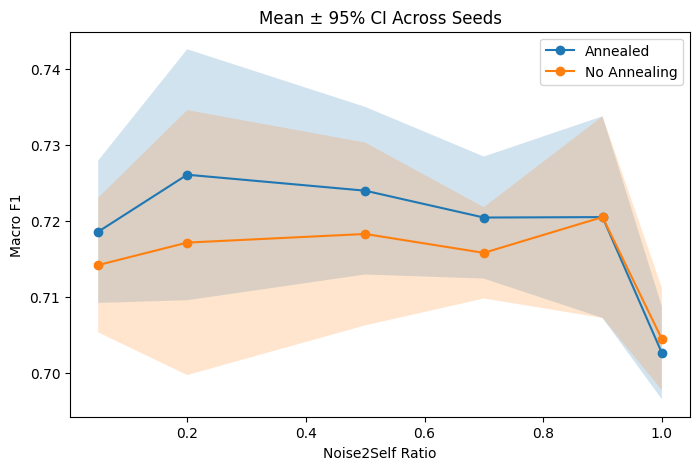

In [62]:
# Mean ± 95% CI
summary = (
    macro
    .groupby("noise2self_ratio")
    .agg(
        mean_anneal=("macro_f1_anneal", "mean"),
        std_anneal=("macro_f1_anneal", "std"),
        mean_noanneal=("macro_f1_noanneal", "mean"),
        std_noanneal=("macro_f1_noanneal", "std"),
        n=("seed", "count")
    )
    .reset_index()
)

summary["ci_anneal"] = 1.96 * summary["std_anneal"] / np.sqrt(summary["n"])
summary["ci_noanneal"]  = 1.96 * summary["std_noanneal"]  / np.sqrt(summary["n"])

plt.figure(figsize=(8,5))
plt.plot(summary["noise2self_ratio"], summary["mean_anneal"], marker="o", label="Annealed")
plt.fill_between(
    summary["noise2self_ratio"],
    summary["mean_anneal"] - summary["ci_anneal"],
    summary["mean_anneal"] + summary["ci_anneal"],
    alpha=0.2
)

plt.plot(summary["noise2self_ratio"], summary["mean_noanneal"], marker="o", label="No Annealing")
plt.fill_between(
    summary["noise2self_ratio"],
    summary["mean_noanneal"] - summary["ci_noanneal"],
    summary["mean_noanneal"] + summary["ci_noanneal"],
    alpha=0.2
)

plt.xlabel("Noise2Self Ratio")
plt.ylabel("Macro F1")
plt.legend()
plt.title("Mean ± 95% CI Across Seeds")
plt.show()
